# LGBC 05 — Evaluation

Evaluate saved validation predictions without retraining the classifier.

In [1]:
# Import libraries
from pathlib import Path
import sys

In [2]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "peak_risk" / "lightgbm"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "peak_risk" / "lightgbm"

REPORTS_DIR, OUTPUTS_DIR

(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/peak_risk/lightgbm'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/peak_risk/lightgbm'))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)


In [4]:
global_metrics = pd.read_csv(REPORTS_DIR / "LGBC_05_global_metrics.csv")
fold_metrics = pd.read_csv(REPORTS_DIR / "LGBC_05_fold_metrics.csv")
fsa_metrics = pd.read_csv(REPORTS_DIR / "LGBC_05_fsa_metrics.csv")
horizon_metrics = pd.read_csv(REPORTS_DIR / "LGBC_05_horizon_metrics.csv")
class_balance = pd.read_csv(REPORTS_DIR / "LGBC_05_class_balance.csv")
threshold_analysis = pd.read_csv(REPORTS_DIR / "LGBC_05_threshold_analysis.csv")
feature_importance = pd.read_csv(REPORTS_DIR / "LGBC_06_feature_importance.csv")

predictions = pd.read_parquet(
    OUTPUTS_DIR / "lightgbm_classifier_validation_predictions.parquet"
)
predictions["forecast_origin"] = pd.to_datetime(predictions["forecast_origin"])
predictions["target_timestamp"] = pd.to_datetime(predictions["target_timestamp"])




In [5]:
# Display Results - Glabal Metrics
display(global_metrics)


,model,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,lightgbm_classifier,0.555288,0.470382,0.509321,0.719957,2519424,7.482544,6.338433,0.053348,0.532379,0.909176


In [6]:
# Display Results - Fold Metrics
display(fold_metrics)


,fold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,0.717059,0.325871,0.448101,0.655018,1257984,10.965243,4.983211,0.073181,0.593187,0.910050
1,fold_2024,0.450744,0.864521,0.592546,0.910260,1261440,4.009386,7.689942,0.033569,0.665852,0.978672


In [7]:
# Display Results - FSA Metrics
display(fsa_metrics)


,fold,fsa,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,L4T,0.331111,0.523594,0.405679,0.751553,209664,1.900183,3.004808,0.022038,0.403933,0.938361
1,fold_2023,M5R,0.471470,0.632510,0.540244,0.809134,209664,1.968864,2.641369,0.015497,0.563784,0.971784
2,fold_2023,M5S,0.363530,0.752415,0.490213,0.865636,209664,1.579670,3.269517,0.017700,0.601633,0.981756
3,fold_2023,M6G,0.728742,0.401095,0.517411,0.696140,209664,5.574634,3.068243,0.033197,0.616267,0.943418
4,fold_2023,M9R,0.499416,0.545867,0.521610,0.763410,209664,3.363954,3.676835,0.025251,0.534428,0.947792
5,fold_2023,M9W,0.978930,0.271155,0.424678,0.632491,209664,51.404151,14.238496,0.325402,0.907905,0.906145
6,fold_2024,L4T,0.438722,0.904082,0.590765,0.935401,210240,2.796804,5.763413,0.024319,0.710168,0.987820
7,fold_2024,M5R,0.320626,0.865363,0.467893,0.917034,210240,1.678082,4.529110,0.023000,0.584009,0.986200
8,fold_2024,M5S,0.358142,0.807073,0.496126,0.893577,210240,1.358447,3.061263,0.015825,0.520720,0.986753
9,fold_2024,M6G,0.406088,0.848615,0.549313,0.900856,210240,3.641553,7.609874,0.036016,0.638110,0.975647


In [8]:
# Display Results - HOrizonts Metrics
display(horizon_metrics)

,fold,horizon,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,1,0.877788,0.328922,0.478531,0.661644,52416,10.956578,4.105617,0.068391,0.739485,0.953918
1,fold_2023,2,0.850362,0.327529,0.472910,0.660219,52416,10.956578,4.220085,0.069325,0.710662,0.944120
2,fold_2023,3,0.846900,0.349643,0.494947,0.670933,52416,10.956578,4.523428,0.066336,0.729156,0.950969
3,fold_2023,4,0.836356,0.329270,0.472514,0.660671,52416,10.956578,4.313568,0.067624,0.720656,0.949479
4,fold_2023,5,0.829513,0.359220,0.501337,0.675068,52416,10.956578,4.744734,0.065482,0.706522,0.942614
5,fold_2023,6,0.811438,0.340937,0.480137,0.665594,52416,10.956578,4.603556,0.067411,0.689117,0.939445
6,fold_2023,7,0.789978,0.315689,0.451107,0.652681,52416,10.956578,4.378434,0.070638,0.656509,0.933579
7,fold_2023,8,0.758770,0.305067,0.435171,0.646566,52416,10.956578,4.405143,0.073303,0.611158,0.914149
8,fold_2023,9,0.749578,0.309594,0.438201,0.648434,52416,10.956578,4.525336,0.072709,0.619471,0.919733
9,fold_2023,10,0.716233,0.292704,0.415575,0.639217,52416,10.956578,4.477640,0.075886,0.579071,0.907661


## Precision-Recall Curve

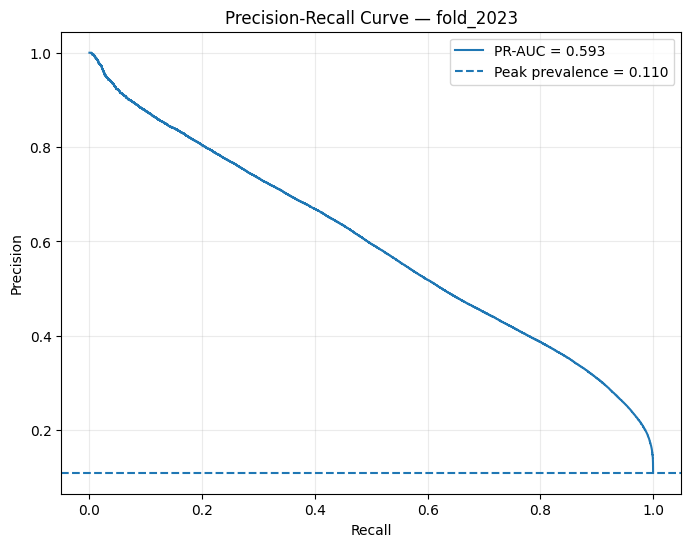

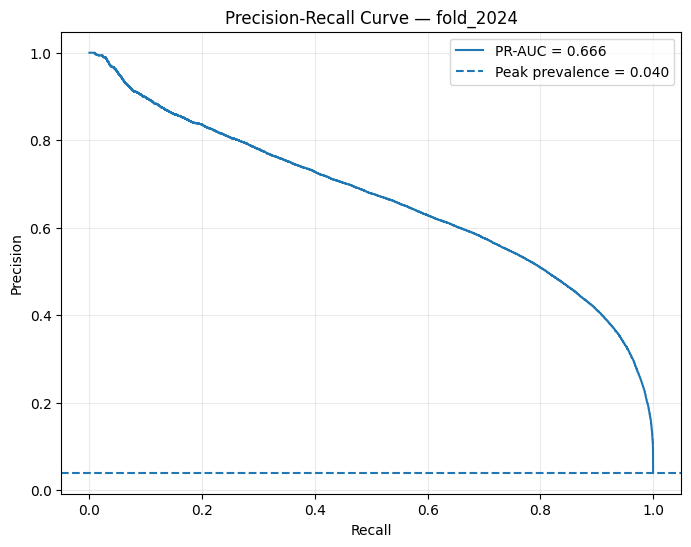

In [9]:
# Precision-Recall curve by validation fold.

for fold, group in predictions.groupby("fold", observed=True):
    precision, recall, _ = precision_recall_curve(
        group["actual"],
        group["probability"],
    )

    pr_auc = average_precision_score(
        group["actual"],
        group["probability"],
    )

    prevalence = group["actual"].mean()

    plt.figure(figsize=(8, 6))
    plt.plot(
        recall,
        precision,
        label=f"PR-AUC = {pr_auc:.3f}",
    )
    plt.axhline(
        prevalence,
        linestyle="--",
        label=f"Peak prevalence = {prevalence:.3f}",
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## ROC Curve

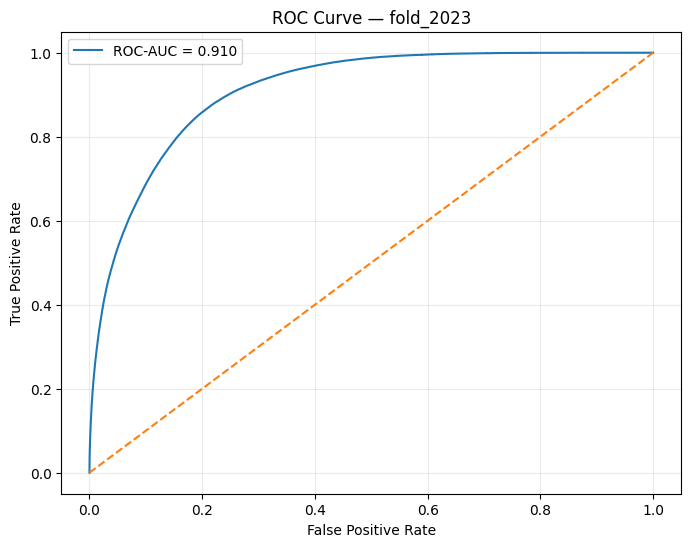

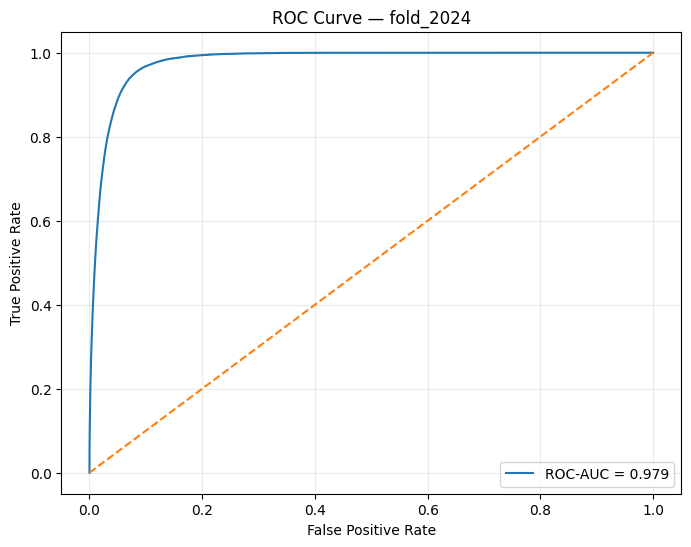

In [10]:
# ROC curve by validation fold.

for fold, group in predictions.groupby("fold", observed=True):
    fpr, tpr, _ = roc_curve(
        group["actual"],
        group["probability"],
    )

    roc_auc = roc_auc_score(
        group["actual"],
        group["probability"],
    )

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr,
        label=f"ROC-AUC = {roc_auc:.3f}",
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
    )
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## Confusion Matrix at Official Threshold 0.50

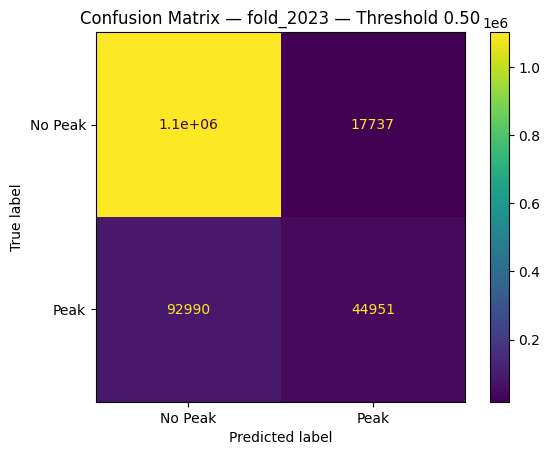

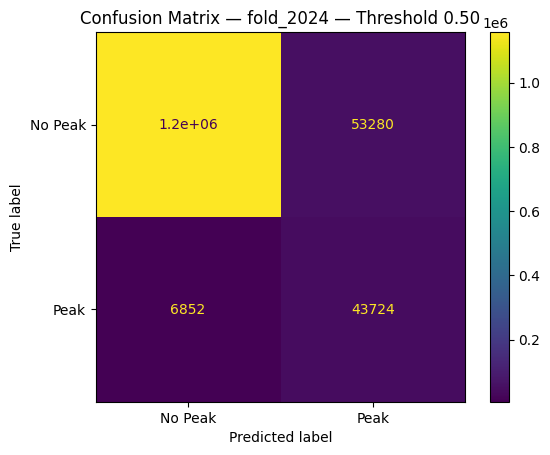

In [11]:
# Confusion matrix by fold at the common comparison threshold.

for fold, group in predictions.groupby("fold", observed=True):
    matrix = confusion_matrix(
        group["actual"],
        group["predicted"],
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No Peak", "Peak"],
    )

    display_matrix.plot()
    plt.title(f"Confusion Matrix — {fold} — Threshold 0.50")
    plt.show()


## Threshold Diagnostics

,threshold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,0.05,0.347114,0.714196,0.467173,0.802776,2519424,7.482544,15.395503,0.053348,0.532379,0.909176
1,0.10,0.391648,0.659203,0.491365,0.788195,2519424,7.482544,12.594268,0.053348,0.532379,0.909176
2,0.15,0.422311,0.624066,0.503738,0.777512,2519424,7.482544,11.057250,0.053348,0.532379,0.909176
3,0.20,0.447296,0.596551,0.511253,0.768467,2519424,7.482544,9.979344,0.053348,0.532379,0.909176
4,0.25,0.468411,0.572543,0.515268,0.759996,2519424,7.482544,9.145979,0.053348,0.532379,0.909176
5,0.30,0.487483,0.550667,0.517152,0.751922,2519424,7.482544,8.452368,0.053348,0.532379,0.909176
6,0.35,0.505123,0.529793,0.517164,0.743907,2519424,7.482544,7.847984,0.053348,0.532379,0.909176
7,0.40,0.521826,0.510018,0.515854,0.736110,2519424,7.482544,7.313219,0.053348,0.532379,0.909176
8,0.45,0.538717,0.490242,0.513338,0.728146,2519424,7.482544,6.809255,0.053348,0.532379,0.909176
9,0.50,0.555288,0.470382,0.509321,0.719957,2519424,7.482544,6.338433,0.053348,0.532379,0.909176


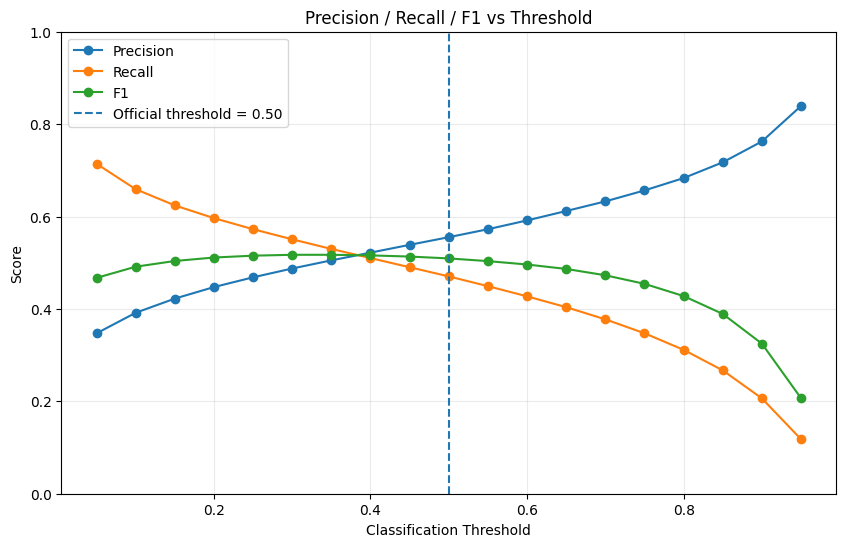

In [12]:
# The threshold sweep is diagnostic only.
# It does not replace the official 0.50 comparison threshold.

display(threshold_analysis)

plt.figure(figsize=(10, 6))
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["precision"],
    marker="o",
    label="Precision",
)
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["recall"],
    marker="o",
    label="Recall",
)
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["f1"],
    marker="o",
    label="F1",
)
plt.axvline(
    0.50,
    linestyle="--",
    label="Official threshold = 0.50",
)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Class Balance

,fold,horizon,observations,actual_peaks,actual_peak_rate_pct
0,fold_2023,1,52416,5743,10.956578
1,fold_2023,2,52416,5743,10.956578
2,fold_2023,3,52416,5743,10.956578
3,fold_2023,4,52416,5743,10.956578
4,fold_2023,5,52416,5743,10.956578
5,fold_2023,6,52416,5743,10.956578
6,fold_2023,7,52416,5743,10.956578
7,fold_2023,8,52416,5743,10.956578
8,fold_2023,9,52416,5743,10.956578
9,fold_2023,10,52416,5743,10.956578


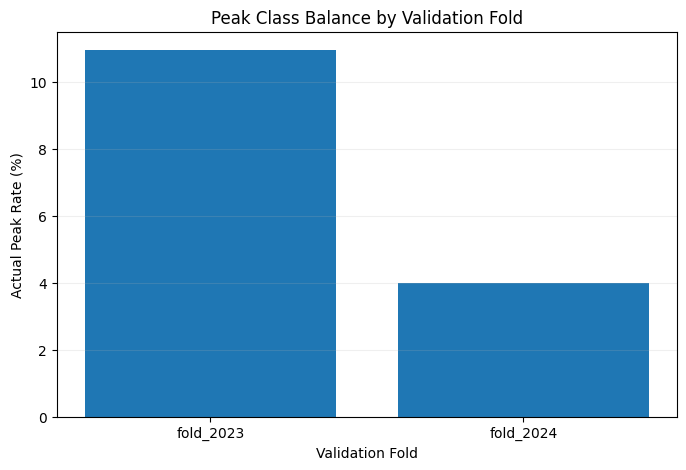

In [13]:
# Actual Peak prevalence by fold and horizon.

display(class_balance)

fold_balance = (
    predictions.groupby("fold", observed=True)["actual"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))
plt.bar(
    fold_balance.index.astype(str),
    fold_balance.values,
)
plt.xlabel("Validation Fold")
plt.ylabel("Actual Peak Rate (%)")
plt.title("Peak Class Balance by Validation Fold")
plt.grid(axis="y", alpha=0.2)
plt.show()


## PR-AUC by Forecast Horizon

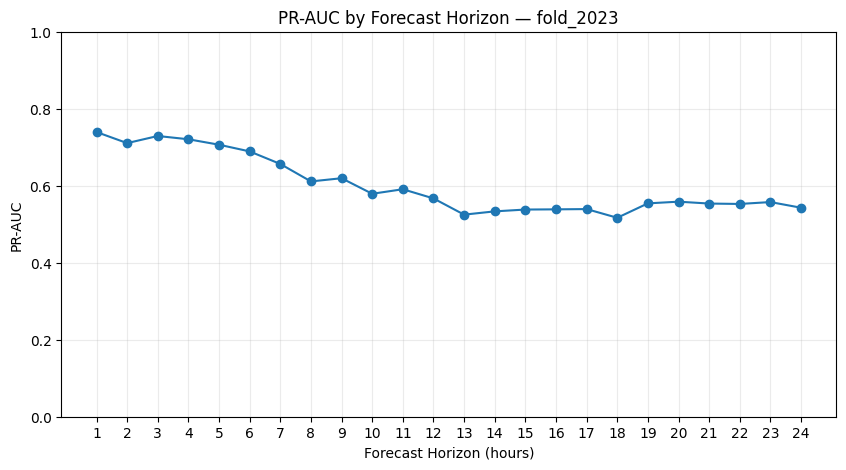

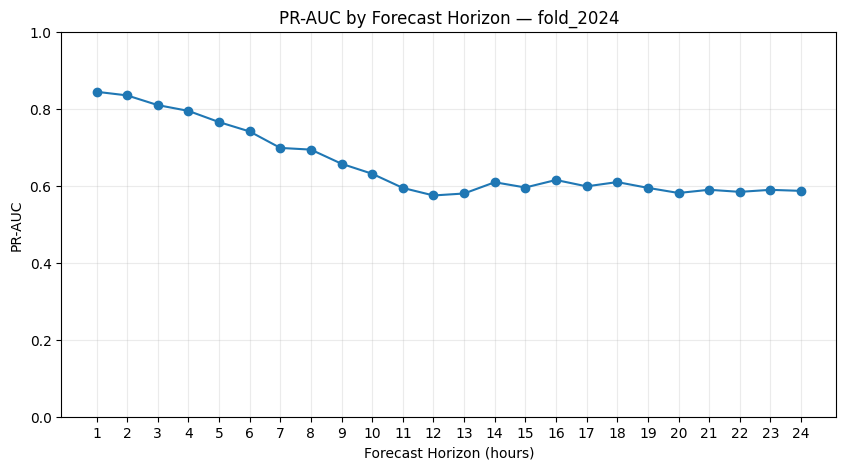

In [14]:
for fold, group in horizon_metrics.groupby("fold", observed=True):
    group = group.sort_values("horizon")

    plt.figure(figsize=(10, 5))
    plt.plot(
        group["horizon"],
        group["pr_auc"],
        marker="o",
    )
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("PR-AUC")
    plt.title(f"PR-AUC by Forecast Horizon — {fold}")
    plt.xticks(range(1, 25))
    plt.ylim(0, 1)
    plt.grid(alpha=0.25)
    plt.show()


## Peak Rate and False Negative Rate by FSA

,fold,fsa,peak_rate_pct
0,fold_2023,L4T,1.900183
1,fold_2023,M5R,1.968864
2,fold_2023,M5S,1.579670
3,fold_2023,M6G,5.574634
4,fold_2023,M9R,3.363954
5,fold_2023,M9W,51.404151
6,fold_2024,L4T,2.796804
7,fold_2024,M5R,1.678082
8,fold_2024,M5S,1.358447
9,fold_2024,M6G,3.641553


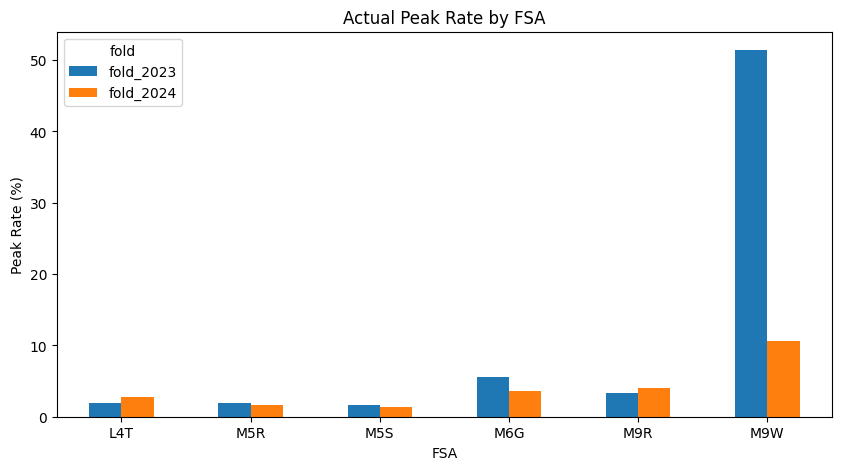

In [15]:
# Peak prevalence by FSA and fold.

fsa_peak_rate = (
    predictions
    .groupby(["fold", "fsa"], observed=True)["actual"]
    .mean()
    .mul(100)
    .reset_index(name="peak_rate_pct")
)

display(fsa_peak_rate)

pivot_peak_rate = fsa_peak_rate.pivot(
    index="fsa",
    columns="fold",
    values="peak_rate_pct",
)

pivot_peak_rate.plot(
    kind="bar",
    figsize=(10, 5),
)
plt.xlabel("FSA")
plt.ylabel("Peak Rate (%)")
plt.title("Actual Peak Rate by FSA")
plt.xticks(rotation=0)
plt.show()


,fold,fsa,actual_peaks,missed_peaks,missed_peak_rate_pct
0,fold_2023,L4T,3984,1898,47.640562
1,fold_2023,M5R,4128,1517,36.749031
2,fold_2023,M5S,3312,820,24.758454
3,fold_2023,M6G,11688,7000,59.890486
4,fold_2023,M9R,7053,3203,45.413299
5,fold_2023,M9W,107776,78552,72.884501
6,fold_2024,L4T,5880,564,9.591837
7,fold_2024,M5R,3528,475,13.463719
8,fold_2024,M5S,2856,551,19.292717
9,fold_2024,M6G,7656,1159,15.138454


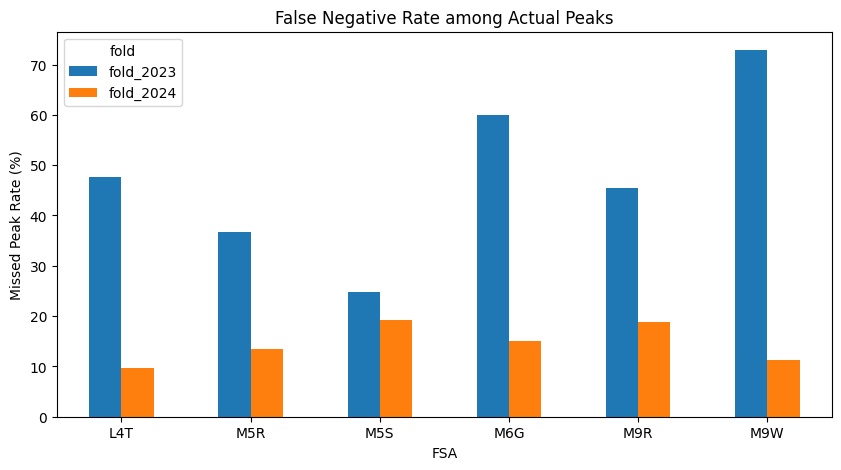

In [16]:
# False Negative Rate among actual Peaks by FSA.

peak_rows = predictions[predictions["actual"] == 1].copy()
peak_rows["missed_peak"] = (
    peak_rows["predicted"] == 0
).astype("int8")

missed_peak_by_fsa = (
    peak_rows
    .groupby(["fold", "fsa"], observed=True)
    .agg(
        actual_peaks=("actual", "size"),
        missed_peaks=("missed_peak", "sum"),
    )
    .reset_index()
)

missed_peak_by_fsa["missed_peak_rate_pct"] = (
    missed_peak_by_fsa["missed_peaks"]
    / missed_peak_by_fsa["actual_peaks"]
    * 100
)

display(missed_peak_by_fsa)

missed_pivot = missed_peak_by_fsa.pivot(
    index="fsa",
    columns="fold",
    values="missed_peak_rate_pct",
)

missed_pivot.plot(
    kind="bar",
    figsize=(10, 5),
)
plt.xlabel("FSA")
plt.ylabel("Missed Peak Rate (%)")
plt.title("False Negative Rate among Actual Peaks")
plt.xticks(rotation=0)
plt.show()


## Monthly Performance

In [17]:
predictions["month"] = (
    predictions["forecast_origin"]
    .dt.to_period("M")
    .astype(str)
)

monthly_rows = []

for (fold, month), group in predictions.groupby(
    ["fold", "month"],
    observed=True,
):
    actual = group["actual"].to_numpy()
    predicted = group["predicted"].to_numpy()
    probability = group["probability"].to_numpy()

    from sklearn.metrics import (
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
    )

    monthly_rows.append(
        {
            "fold": fold,
            "month": month,
            "observations": len(group),
            "actual_peak_rate_pct": actual.mean() * 100,
            "precision": precision_score(
                actual, predicted, zero_division=0
            ),
            "recall": recall_score(
                actual, predicted, zero_division=0
            ),
            "f1": f1_score(
                actual, predicted, zero_division=0
            ),
            "pr_auc": (
                average_precision_score(actual, probability)
                if len(np.unique(actual)) == 2
                else np.nan
            ),
        }
    )

monthly_metrics = pd.DataFrame(monthly_rows)
display(monthly_metrics)


,fold,month,observations,actual_peak_rate_pct,precision,recall,f1,pr_auc
0,fold_2023,2023-01,107136,9.340464,0.732080,0.330669,0.455565,0.643843
1,fold_2023,2023-02,96768,11.170015,0.753204,0.277269,0.405329,0.638701
2,fold_2023,2023-03,107136,17.474052,0.659358,0.428877,0.519710,0.606756
3,fold_2023,2023-04,103680,11.009838,0.763636,0.003679,0.007323,0.673085
4,fold_2023,2023-05,107136,11.741151,0.736999,0.235472,0.356910,0.655276
5,fold_2023,2023-06,103680,2.681327,0.317613,0.118705,0.172820,0.211494
6,fold_2023,2023-07,107136,7.707027,0.393075,0.233741,0.293157,0.334596
7,fold_2023,2023-08,107136,2.545363,0.235154,0.108911,0.148872,0.162287
8,fold_2023,2023-09,103680,19.785880,0.790218,0.470995,0.590208,0.746896
9,fold_2023,2023-10,107136,12.914427,0.890173,0.022261,0.043435,0.740502


In [ ]:
for fold, group in monthly_metrics.groupby("fold", observed=True):
    plt.figure(figsize=(12, 5))
    plt.plot(
        group["month"],
        group["pr_auc"],
        marker="o",
        label="PR-AUC",
    )
    plt.plot(
        group["month"],
        group["recall"],
        marker="o",
        label="Recall",
    )
    plt.xlabel("Month")
    plt.ylabel("Score")
    plt.title(f"Monthly Peak-Risk Performance — {fold}")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## Probability Distribution

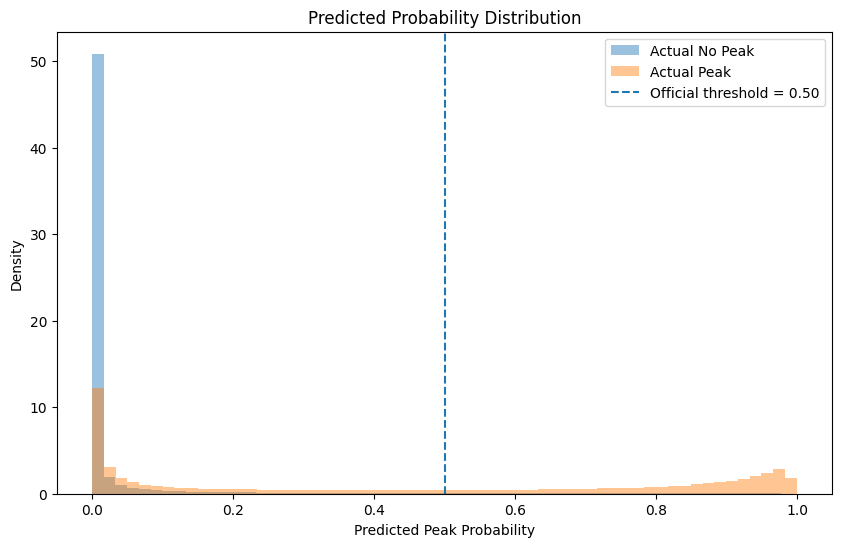

In [18]:
no_peak = predictions.loc[
    predictions["actual"] == 0,
    "probability",
]

peak = predictions.loc[
    predictions["actual"] == 1,
    "probability",
]

plt.figure(figsize=(10, 6))
plt.hist(
    no_peak,
    bins=60,
    density=True,
    alpha=0.45,
    label="Actual No Peak",
)
plt.hist(
    peak,
    bins=60,
    density=True,
    alpha=0.45,
    label="Actual Peak",
)
plt.axvline(
    0.50,
    linestyle="--",
    label="Official threshold = 0.50",
)
plt.xlabel("Predicted Peak Probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()


## Calibration / Brier Diagnostic

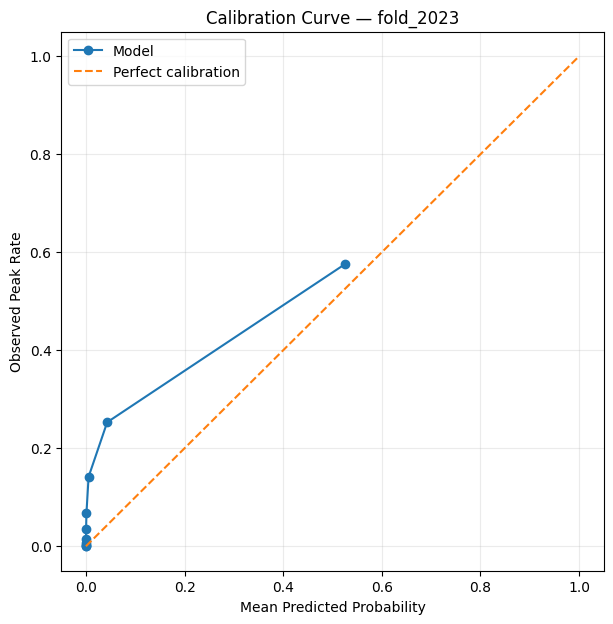

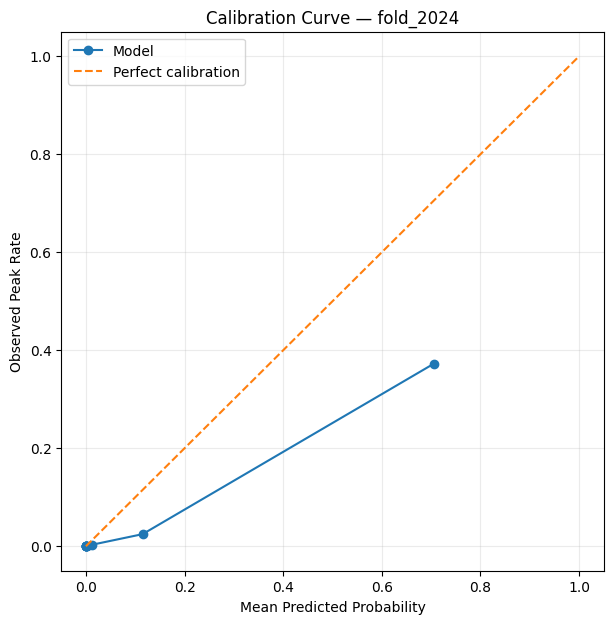

In [19]:
# Reliability curve by fold.
# Calibration and Brier score are supplementary diagnostics, not the common
# model-selection metric.

for fold, group in predictions.groupby("fold", observed=True):
    fraction_of_positives, mean_predicted = calibration_curve(
        group["actual"],
        group["probability"],
        n_bins=10,
        strategy="quantile",
    )

    plt.figure(figsize=(7, 7))
    plt.plot(
        mean_predicted,
        fraction_of_positives,
        marker="o",
        label="Model",
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Peak Rate")
    plt.title(f"Calibration Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## Actual Peak Detection Timeline

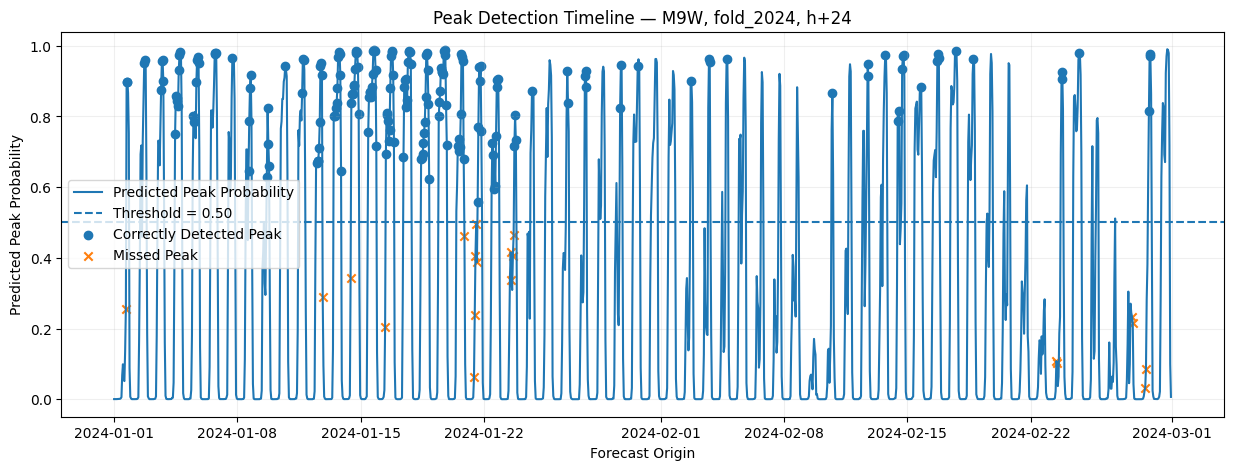

In [20]:
# Representative h+24 M9W timeline.
# Correctly detected and missed Peaks are displayed against predicted risk.

timeline = (
    predictions[
        (predictions["fold"] == "fold_2024")
        & (predictions["fsa"] == "M9W")
        & (predictions["horizon"] == 24)
    ]
    .sort_values("forecast_origin")
    .head(24 * 60)
    .copy()
)

plt.figure(figsize=(15, 5))
plt.plot(
    timeline["forecast_origin"],
    timeline["probability"],
    label="Predicted Peak Probability",
)
plt.axhline(
    0.50,
    linestyle="--",
    label="Threshold = 0.50",
)

correct = timeline[
    (timeline["actual"] == 1)
    & (timeline["predicted"] == 1)
]
missed = timeline[
    (timeline["actual"] == 1)
    & (timeline["predicted"] == 0)
]

plt.scatter(
    correct["forecast_origin"],
    correct["probability"],
    marker="o",
    label="Correctly Detected Peak",
)
plt.scatter(
    missed["forecast_origin"],
    missed["probability"],
    marker="x",
    label="Missed Peak",
)

plt.xlabel("Forecast Origin")
plt.ylabel("Predicted Peak Probability")
plt.title("Peak Detection Timeline — M9W, fold_2024, h+24")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Feature Importance

,feature,importance
0,origin__Temp (°C),1239.770833
1,origin__Stn Press (kPa),868.020833
2,origin__reported_premise_count,718.312500
3,target_lag_24h,585.041667
4,origin__Rel Hum (%),547.479167
5,origin_rolling_std_24h,502.208333
6,origin_rolling_mean_24h,476.250000
7,origin_rolling_mean_168h,465.666667
8,target_lag_168h,444.062500
9,target_hour,350.312500


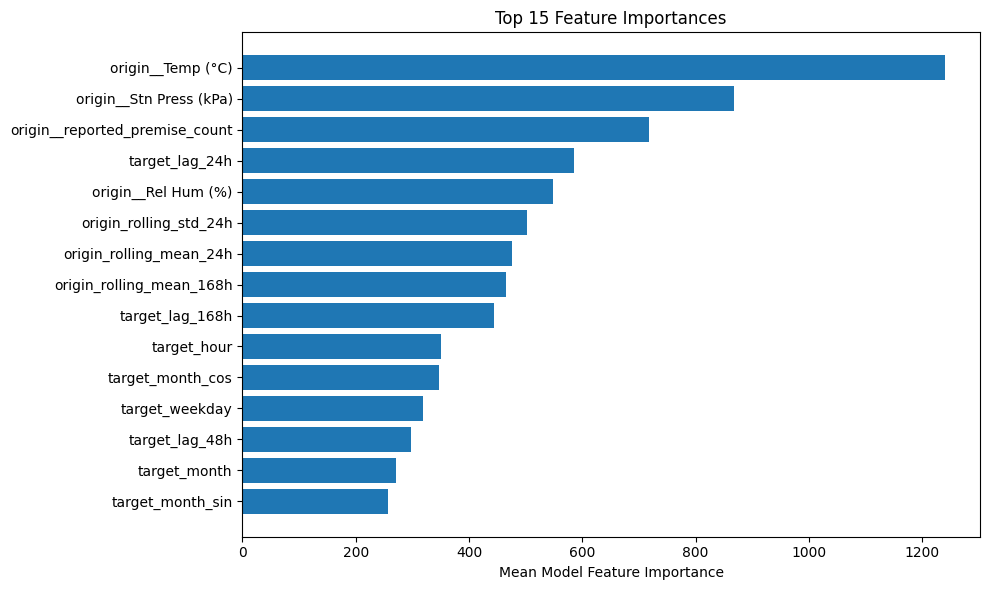

In [21]:
display(feature_importance.head(20))

plot_data = (
    feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["feature"],
    plot_data["importance"],
)
plt.xlabel("Mean Model Feature Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


## Additional Model Stability Diagnostics

These diagnostics mirror the additional analyses used for the Random Forest and XGBoost classifiers. They use only the validation predictions already loaded in this notebook and **do not retrain LightGBM**.

They evaluate:

1. performance with and without the M9W-2023 structural stress case;
2. macro-average performance across FSAs;
3. threshold stability separately by validation fold.

In [ ]:
# ============================================================
# Additional diagnostic 1
# Global metrics with and without M9W-2023
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
)

def evaluate_subset(frame, label):
    y_true = frame["actual"].astype(int)
    y_pred = frame["predicted"].astype(int)
    y_prob = frame["probability"].astype(float)

    return {
        "segment": label,
        "observations": len(frame),
        "peak_rate_pct": y_true.mean() * 100,
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "pr_auc": (
            average_precision_score(
                y_true,
                y_prob,
            )
            if y_true.nunique() == 2
            else np.nan
        ),
        "roc_auc": (
            roc_auc_score(
                y_true,
                y_prob,
            )
            if y_true.nunique() == 2
            else np.nan
        ),
        "brier_score": brier_score_loss(
            y_true,
            y_prob,
        ),
    }


m9w_2023_mask = (
    (predictions["fold"] == "fold_2023")
    &
    (predictions["fsa"] == "M9W")
)

comparison = pd.DataFrame(
    [
        evaluate_subset(
            predictions,
            "All validation data",
        ),
        evaluate_subset(
            predictions.loc[~m9w_2023_mask],
            "Excluding M9W-2023",
        ),
        evaluate_subset(
            predictions.loc[m9w_2023_mask],
            "M9W-2023 only",
        ),
    ]
)

display(comparison)


### Macro-Average Performance Across FSAs

In [ ]:
# ============================================================
# Additional diagnostic 2
# Macro-average metrics across FSA
# ============================================================

macro_fsa = (
    fsa_metrics
    .groupby(
        "fold",
        observed=True,
    )
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1", "mean"),
        macro_pr_auc=("pr_auc", "mean"),
        macro_roc_auc=("roc_auc", "mean"),
        macro_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
    )
    .reset_index()
)

display(macro_fsa)


In [ ]:
# Plot macro-average metrics across FSAs.

macro_plot = macro_fsa.set_index("fold")[
    [
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "macro_pr_auc",
    ]
]

macro_plot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.ylabel("Score")
plt.title(
    "LightGBM Classifier — "
    "Macro-Average Performance Across FSAs"
)

plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### Threshold Stability by Validation Fold

In [ ]:
# ============================================================
# Additional diagnostic 3
# Threshold analysis by validation fold
# ============================================================

threshold_values = np.arange(
    0.05,
    0.96,
    0.05,
)

threshold_fold_rows = []

for fold, group in predictions.groupby(
    "fold",
    observed=True,
):

    y_true = group["actual"].astype(int)
    y_prob = group["probability"].astype(float)

    for threshold in threshold_values:

        y_pred = (
            y_prob >= threshold
        ).astype(int)

        threshold_fold_rows.append(
            {
                "fold": fold,
                "threshold": threshold,
                "precision": precision_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
                "recall": recall_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
                "f1": f1_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
            }
        )

threshold_by_fold = pd.DataFrame(
    threshold_fold_rows
)

display(threshold_by_fold)


In [ ]:
# Plot threshold diagnostics separately for each validation fold.

for fold, group in threshold_by_fold.groupby(
    "fold",
    observed=True,
):

    plt.figure(figsize=(10, 5))

    plt.plot(
        group["threshold"],
        group["precision"],
        marker="o",
        label="Precision",
    )

    plt.plot(
        group["threshold"],
        group["recall"],
        marker="o",
        label="Recall",
    )

    plt.plot(
        group["threshold"],
        group["f1"],
        marker="o",
        label="F1",
    )

    plt.axvline(
        0.50,
        linestyle="--",
        label="Official threshold = 0.50",
    )

    best_row = group.loc[
        group["f1"].idxmax()
    ]

    plt.axvline(
        best_row["threshold"],
        linestyle=":",
        label=(
            "Best F1 threshold = "
            f"{best_row['threshold']:.2f}"
        ),
    )

    plt.xlabel("Classification Threshold")
    plt.ylabel("Score")

    plt.title(
        f"LightGBM — Threshold Diagnostics ({fold})"
    )

    plt.ylim(0, 1)

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


In [ ]:
# Summarize the F1-optimal diagnostic threshold by fold.

best_threshold_by_fold = (
    threshold_by_fold
    .loc[
        threshold_by_fold
        .groupby("fold")["f1"]
        .idxmax()
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)

display(best_threshold_by_fold)
